# Mobile Robotics - Assignment 3 (TP3)
### Thiago Lages (2024709332)

## Code structure

- The code has been made to be modular and easy to implement for the next
assignments. 
- Thus, an `Assignment` class was created with common code that will
be used in all assignments.

- A `CoppeliaSimAPI` class was also created to make
connection with CoppeliaSim easier and encapsulated.

- A `HokuyoSensorSim` data was also used to make it easier to get data
from the sensor inside sim. Credits to Prof. Douglas Macharet, professor of
this Mobile Robotics subject for providing that.

- Finally, an `utils` file has been used for various utility functions that are
needed throughout this notebook. Since we'll be dealing with CoppeliaSim's 
`RemoteAPI`, some functions return poses with 7 elements (x,y,z,qw,qx,qy,qz),
other return 3x4 matrices, which are not homogeneous transformation matrices, 
etc., which created the need to implement functions such as `tf_from_pose`,
`get_tf`, etc. In addition, since many plots had to be done during this
assignment, other functions such as `plot_sensor_data`, `plot_robot_to_object_tfs`
had to be implemented as well.
- The main class of this assignment, called `TP1`, inherits from `Assignment`
and implements both the `run` abstract method of `Assignment`, as well as each
proposed exercise in `TP1.pdf`.

- Each exercise is run sequentially to that each one can be shown inside this
Jupyter notebook.

## How to run
- Make sure your python environment has all packages inside `requirements.txt`.
  - If you want, just run `pip install -r requirements.txt` on your py env
- Make sure CoppeliaSim is running with the provided scene (TP1.ttt)
- Make sure the `ZeroMQ` remote API server has started using port `23000`
- Run all cells of this notebook using `Run All`
- The code will run for all cells, and the plots will be done in this notebook.
- For the last question, #6, the simulation will run for around `30s`,
and the final robot path will be plotted at the end.

In [261]:
from matplotlib import pyplot as plt

# Ensure plots are rendered inline in the notebook
%matplotlib inline
# Configure matplotlib for interactive, non-blocking plots
plt.ion()  # Enable interactive mode

## CoppeliaSimAPI


In [262]:
from coppeliasim_zmqremoteapi_client import RemoteAPIClient


class CoppeliaSimAPI:
    def __init__(self, port=23000, stepping=True, verbose=None):
        """
        Initialize the CoppeliaSim API client.
        """
        # Create a RemoteAPIClient instance to connect to CoppeliaSim
        # The port number should match the one in CoppeliaSim's remote API
        # settings port as set via -GzmqRemoteApi.rpcPort
        print("-" * 40)
        print(f"Trying to connect to CoppeliaSim API on port {port}")
        self.client = RemoteAPIClient("localhost", port, verbose=verbose)
        self.sim = self.client.require("sim")
        self.simIK = self.client.require("simIK")

        print("Connected to CoppeliaSim API.")
        api_version = self.sim.getInt32Param(self.sim.intparam_program_version)
        print(f"API version: {api_version}")
        self.stepping = stepping
        self.sim.setStepping(self.stepping)
        self.dt = self.sim.getSimulationTimeStep()
        print("Simulation time step:", self.dt)
        print("-" * 40)

    def start(self):
        self.sim.startSimulation()

    def resume(self):
        self.start()

    def pause(self):
        self.sim.pauseSimulation()

    def stop(self):
        self.sim.stopSimulation()

    def step(self):
        self.sim.step()

    def get_simulation_time(self):
        return self.sim.getSimulationTime()


## Assignment class

In [263]:
import os
import time
from abc import abstractmethod

class Assignment:
    def __init__(self, sleep=True, auto_start=True, stepping=False, verbose=0):
        if sleep:
            print("Waiting for CoppeliaSim to open...")
            time.sleep(3)
        self.port = os.environ.get("COPPELIA_ZMQ_PORT", 23000)
        try:
            self.simAPI = CoppeliaSimAPI(
                port=self.port, stepping=stepping, verbose=int(verbose)
            )
            self.sim = self.simAPI.sim
            self.simIK = self.simAPI.simIK
            if auto_start:
                self.simAPI.start()
                time.sleep(1)  # wait for the simulation to start
        except Exception as e:
            print("CoppeliaSim not reachable (this is fine in CI):", e)
            exit(1)

    @abstractmethod
    def run(self):
        pass


# HokuyoSensorSim Class

In [264]:
import math

import numpy as np


class HokuyoSensorSim(object):
    """
    Simulates a Hokuyo laser sensor in CoppeliaSim using vision sensors.

    This class provides an interface to interact with a simulated Hokuyo sensor,
    typically attached to a robot in CoppeliaSim. It manages the underlying vision
    sensors and provides methods to retrieve sensor data in either range or point format.

    Attributes:
        _sim: The simulation API object used to interact with CoppeliaSim.
        _base_name (str): The name of the base object to which the Hokuyo sensor is attached.
        _is_range_data (bool): Determines if sensor data is returned as range values (True) or 3D points (False).
        _base_obj: The handle of the base object in the simulation.
        _vision_sensors_obj (list): Handles of the vision sensors used to simulate the Hokuyo sensor.

    Args:
        sim: The simulation API object.
        laser_name (str): The name of the base object (must contain 'fastHokuyo').
        is_range_data (bool, optional): If True, sensor data is returned as range values. Defaults to False.

    Raises:
        ValueError: If 'fastHokuyo' is not in the laser_name, or if the base object or vision sensors are not found.

    Methods:
        get_is_range_data() -> bool:
            Returns whether sensor data is returned as range values.

        set_is_range_data(is_range_data: bool) -> None:
            Sets whether sensor data should be returned as range values.

        getSensorData():
            Retrieves sensor data from the vision sensors.
            Returns either a list of range values or a list of 3D points, depending on _is_range_data.
    """

    _sim = None

    _base_name = ""
    _vision_sensor_name_template = "{0}/fastHokuyo_body/fastHokuyo_joint{1}/fastHokuyo_sensor{1}"

    # _vision_sensors_obj will be initialized in __init__
    _base_obj = None
    _is_range_data = False

    angle_laser = 90
    _angle_min = -angle_laser * math.pi / 180
    _angle_max = angle_laser * math.pi / 180
    _angle_increment = (2*angle_laser / 684) * math.pi / 180  # angle: 180 deg, pts: 684

    def __init__(self, sim, laser_name, is_range_data=True):
        self._sim = sim
        self._base_name = laser_name
        self._handle = sim.getObject(self._base_name)
        self._is_range_data = is_range_data

        print(
            f"HokuyoSensorSim: laser_name: {self._base_name}, handle: {self._handle}"
        )

        if "fastHokuyo" not in laser_name:
            raise ValueError(
                f"ERR: fastHokuyo must be in the base object name. Ex: `/PioneerP3DX/fastHokuyo`"
            )

        if self._handle == -1:
            raise ValueError(
                f"ERR: base_obj ({self._handle}) is not a valid name in the simulation"
            )

        self._vision_sensors_obj = [
            sim.getObject(self._vision_sensor_name_template.format(self._base_name, 1)),
            sim.getObject(self._vision_sensor_name_template.format(self._base_name, 2))
        ]

        if any(obj == -1 for obj in self._vision_sensors_obj):
            raise ValueError(
                f"ERR: the _vision_sensors_obj names are not valid in the simulation"
            )

    def get_is_range_data(self) -> bool:
        return self._is_range_data

    def set_is_range_data(self, is_range_data: bool) -> None:
        self._is_range_data = is_range_data

    def getSensorData(self, max_sensor_range=5.0, verbose=False):

        angle = self._angle_min
        sensor_data = []
        max_range_factor = 0.99 # between 0.9 and 1.0

        for vision_sensor in self._vision_sensors_obj:
            r, t, u = self._sim.readVisionSensor(vision_sensor)
            if u:
                sensorM = self._sim.getObjectMatrix(vision_sensor)
                relRefM = self._sim.getObjectMatrix(self._handle)
                relRefM = self._sim.getMatrixInverse(relRefM)
                relRefM = self._sim.multiplyMatrices(relRefM, sensorM)

                p = [0, 0, 0]
                p = self._sim.multiplyVector(sensorM, p)
                t = [p[0], p[1], p[2], 0, 0, 0]
                for j in range(int(u[1])): # num lasers (only 1 for each vision sensor)
                    # print(f"j: {j}")
                    for i in range(int(u[0])): # num laser beams
                        # we add 2 to skip first and second values of u, which
                        # are number of lasers (1) and number of beams (342)
                        # Then we iterate 4 values at once, since we're getting
                        # w, w+1, w+2 and w+3
                        w = 2 + 4 * (j * int(u[0]) + i)
                        v = [u[w], u[w + 1], u[w + 2], u[w + 3]]
                        angle = angle + self._angle_increment

                        # Add noise to the range measurement
                        # noise = 2*(np.random.random()-0.5) # [-1, +1]
                        noise = 0.0
                        
                        v[3] += noise * 10 / 100.0 # +-10cm
                        angle += np.deg2rad(noise * 5) # +-5 degrees


                        if v[3] < 0 or v[3] >= (max_sensor_range + noise) * max_range_factor: # out of bounds
                            continue
                        if self._is_range_data:
                            sensor_data.append([angle, v[3]])
                        else:
                            p = self._sim.multiplyVector(relRefM, v)
                            p = [_p + noise for _p in p]
                            sensor_data.append([p[0], p[1], p[2]])

        res = np.array(sensor_data)
        if verbose:
            print("-" * 40)
            print(f"HokuyoSensorSim: sensor_data: \n {res}")
        return res


# TP3 Class

----------------------------------------
Trying to connect to CoppeliaSim API on port 23000
Connected to CoppeliaSim API.
API version: 41000
Simulation time step: 0.05
----------------------------------------
Rows: 20, Cols: 20
Building object dictionary
Found 0 handles: []
HokuyoSensorSim: laser_name: /kobuki/fastHokuyo, handle: 145
HokuyoSensorSim: laser_name: /kobuki/fastHokuyo, handle: 145
----------------------------------------
Starting simulation
----------------------------------------
icell_size: 0, cell_size: 0.5

Starting iteration 1/1 with cell_size=0.5

current_waypoint: [1.0, 4.0]
current_waypoint: [1.0, 4.0]
vx_rep, vy_rep: 0, 0
vx_rep, vy_rep before repulsion: 0, 0
vx_rep, vy_rep after repulsion: 0, 0
w_left_raw, w_right_raw: 11.3126777425284, 17.25875082890017
current_waypoint: [1.0, 4.0]
vx_rep, vy_rep: 0, 0
vx_rep, vy_rep before repulsion: 0, 0
vx_rep, vy_rep after repulsion: 0, 0
w_left_raw, w_right_raw: 11.341542802433931, 17.229885768994635
current_waypoint: [1.0,

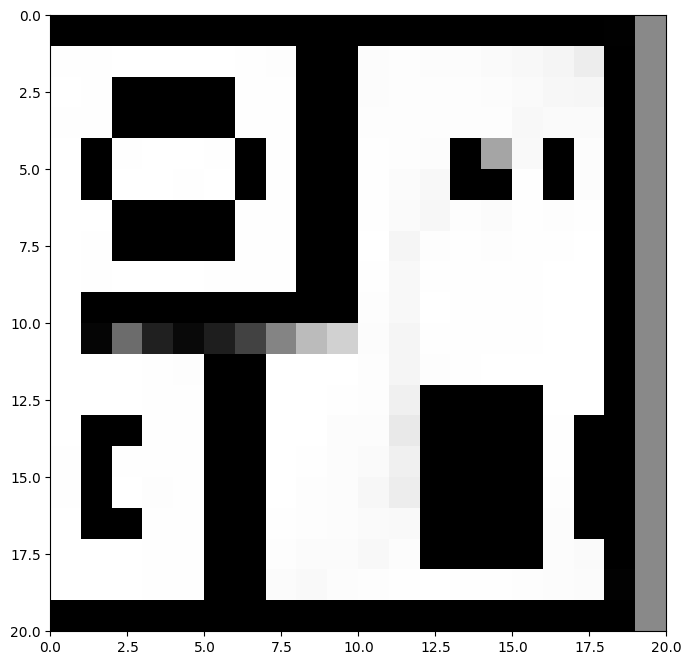

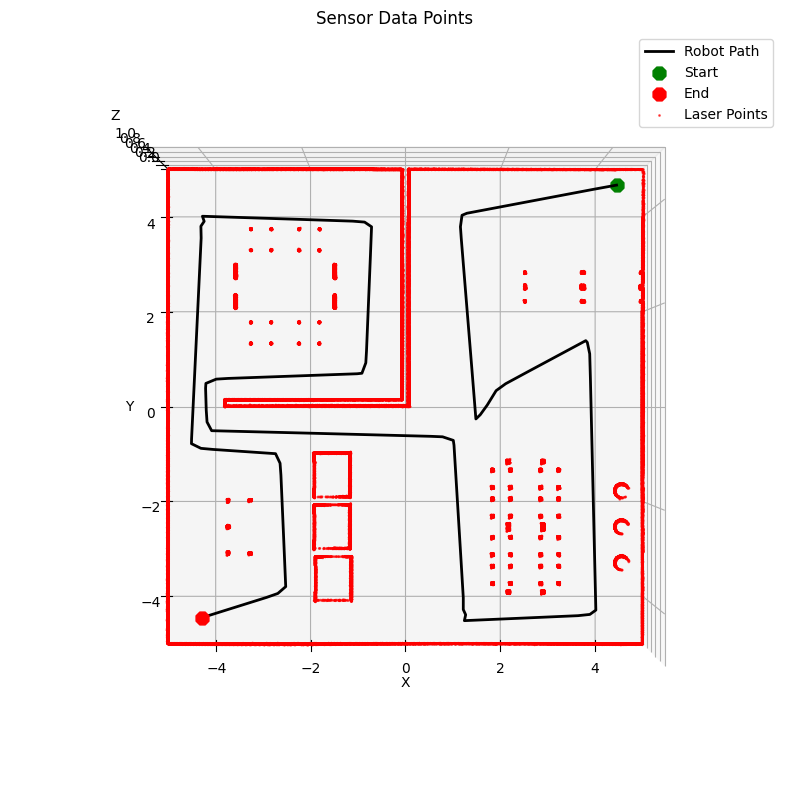

In [265]:
import numpy as np
from matplotlib import pyplot as plt
from skimage.draw import line

# Ensure plots are rendered inline in the notebook
%matplotlib inline
# Configure matplotlib for interactive, non-blocking plots
plt.ion()  # Enable interactive mode

from utils import (
    build_object_dict,
    get_tf,
    handle_sim_start,
    plot_sensor_data,
)

import time

# Configure numpy to display matrices with at most 2 decimal places
np.set_printoptions(precision=2, suppress=True)

class TP3(Assignment):
    def __init__(self, verbose=False):
        super().__init__(sleep=False, auto_start=False, stepping=True)
        self.verbose = verbose
        self._setup()

        # TEST
        # self.sim.setStepping(False)

    def _setup(self):
        
        self.next_waypoint_index = -1
        self.target_waypoints = [
            [-4.5, -4.5],
            [-2.5, -4.0],
            [-2.5, -1.0],
            [-4.5, -1.0],
            [-4.5, 4.0],
            [-0.7, 4.0],
            [-0.7, 0.7],
            [-4.2, 0.7],
            [-4.3, -0.5],
            [1.0, -0.5],
            [1.0, -4.5],
            [4.0, -4.5],
            [4.0, 1.5],
            [2.0, 0.5],
            [1.5, -0.5],
            [1.0, 4.0],
            [4.0, 4.0],

        ]
        self.target_waypoints.reverse()

        self.ax = None
        self.reached_all_waypoints = False
        self.robot_path = []
        self.printed_current_waypoint = False
        self.P_world_array = None
        self.current_waypoint = None
        self.last_plotted_path_index = 0  # Track how much of the path has been plotted
        self.start_marker_plotted = False  # Track if start marker has been plotted
        self.last_plotted_sensor_count = 0  # Track how many sensor points have been plotted
        self.legend_added = False  # Track if legend has been added
        self.plt_perspective_view = (60, -130, -15)  # elev, azim, roll
        self.plt_top_view = (90, -90, 0)  # elev, azim, roll
        self.max_sensor_range = 5.0
        self.max_range_factor = 0.95

        self.plot_x_range = [-3, 3]
        self.plot_y_range = [-3, 3]
        self.plot_z_range = [0, 1]

        ## -- Occupancy Grid -- ##
        # Use only the wanted cell size
        self.cell_sizes = [0.5] #, 0.01, 0.05, 0.1]
        self.cell_size = self.cell_sizes[0]
        self.num_cell_sizes = len(self.cell_sizes)
        self.map_size = 10 # m
        self.map_limits = [-self.map_size/2, self.map_size/2]
        self.rows = self.cols = int(self.map_size/self.cell_size)
        # This is important. It has to represent a probability at around 0.5
        # but it CAN'T be log(1) = 0, otherwise we won't be able to update
        # the map.
        self.l0 = np.log(1.2)
        # Create one map for each cell size
        self._map_log_odds = []
        for cell_size in self.cell_sizes:
            rows = cols = int(self.map_size/cell_size)
            self._map_log_odds.append(
                np.ones((rows, cols)) * self.l0
            )

        print(f"Rows: {self.rows}, Cols: {self.cols}")
        ## -- Occupancy Grid -- ##

        ## -- Controller -- ##
        # Gains
        self.kv = 0.05 #1 # 1
        self.kw = 5 # 1

        self.L = 0.230
        self.r = 0.035

        self.maxv = 0.5 #valor padrão
        self.maxw = np.deg2rad(360)

        self.waypoints = []
        self.reached_waypoint = False
        self.waypoint_tolerance = 0.25  # meters
        ## -- Controller -- ##

        ## -- Obstacle Avoidance -- ##
        self.min_obstacle_distance = 1.0 # circle of radius X


        self.robot_name = "/kobuki"
        self.laser_name = "/kobuki/fastHokuyo"
        self.motor_right_name =(
            self.robot_name + 
            "/wheel_right_drop_sensor/wheel_right_drop_respondable/" +
            "kobuki_rightMotor"
        )
        self.motor_left_name = (
            self.robot_name + 
            "/wheel_left_drop_sensor/wheel_left_drop_respondable/" +
            "kobuki_leftMotor"
        )

        self.excluded_objects = [
            self.robot_name, # Exclude robot from objects
            "DefaultCamera",
            "XYZCameraProxy",
            "DefaultLights",
            "Floor",
            "robot_frame",
            "world_frame"
        ]
        self.robot_handle = self.sim.getObject(self.robot_name)
        self.laser_handle = self.sim.getObject(self.laser_name)
        self.motorLeft_handle = self.sim.getObject(self.motor_left_name)
        self.motorRight_handle = self.sim.getObject(self.motor_right_name)

        self.objects = build_object_dict(
            self.sim, 
            self.excluded_objects, 
            verbose=self.verbose
        )

        self.hokuyo_sensor = HokuyoSensorSim(self.sim, self.laser_name)
        self.hokuyo_sensor.set_is_range_data(
            False
        )  # Get points in laser frame
        self.hokuyo_sensor_range = HokuyoSensorSim(self.sim, self.laser_name)
        self.hokuyo_sensor_range.set_is_range_data(
            True
        )  # Get points as (angle, distance)

        # Setup robot angular velocity for each wheel
        self.set_robot_velocity(0, 0)

    def setupExercises(self):

        # Create plots directory if it doesn't exist
        os.makedirs("plots", exist_ok=True)
        
        handle_sim_start(self.sim)
        self.dt = self.sim.getSimulationTimeStep()
        
        # Save initial robot pose
        self.robot_initial_pose_list = (
            self.sim.getObjectPose(self.robot_handle)
        )
        self.robot_initial_pose = (
            self.sim.poseToMatrix(self.robot_initial_pose_list)
        )
        
        # Get current robot, laser and objects poses
        self.get_robot_tfs(verbose=self.verbose)
        self.get_laser_tfs(verbose=self.verbose)

        # Since this transform is static, it needs to be calculated only once
        self.T_robot_laser = self.T_robot_w @ self.T_w_laser

    def get_laser_tfs(self, verbose=False):
        print("Getting laser tf")
        self.T_w_laser = get_tf(
            self.sim, self.laser_handle, verbose=self.verbose
        )  # 4 x 4 matrix
        self.T_laser_w = get_tf(
            self.sim, self.laser_handle, inv=True, verbose=self.verbose
        )  # 4 x 4 matrix

    def get_robot_tfs(self, verbose=False):
        if verbose:
            print("Getting robot tf")
        self.T_w_robot = get_tf(
            self.sim, self.robot_handle, verbose=self.verbose
        )  # 4 x 4 matrix
        self.T_robot_w = get_tf(
            self.sim, self.robot_handle, inv=True, verbose=self.verbose
        )  # 4 x 4 matrix
  
    def get_laser_world(self):

        # Get laser data
        P_laser = self.hokuyo_sensor.getSensorData()
        
        # Normalize vectors
        P_laser = np.hstack(
            [np.array(P_laser), np.ones((len(P_laser), 1))]
        )
        # Transpose to get 4 x N
        P_laser = P_laser.T

        # Get laser points in world coordinates
        P_world = self.T_w_robot @ self.T_robot_laser @ P_laser
        
        return P_world

    
    def get_robot_and_laser_cell_idx_vectorized(self, robot_pos, p_world_array):
        """
        Vectorized version: Transform multiple points from world coordinates to cell coordinates
        Args:
            robot_pos: (x, y) tuple or array of robot position
            p_world_array: N x 2 array of world coordinates (only x, y)
        Returns:
            (xi, yi, xoi, yoi) - all as arrays of shape (N,)
        """
        # Robot position
        x, y = robot_pos[:2]

        # Extract x and y coordinates from all points
        xo = p_world_array[:, 0]
        yo = p_world_array[:, 1]
        
        # Clip to map limits (vectorized)
        xo = np.clip(xo, self.map_limits[0], self.map_limits[1])
        yo = np.clip(yo, self.map_limits[0], self.map_limits[1])

        # Convert to cell indices (vectorized)
        xi = np.floor((1/self.cell_size) * x).astype(int)
        yi = np.floor((1/self.cell_size) * y).astype(int)
        xoi = np.floor((1/self.cell_size) * xo).astype(int)
        yoi = np.floor((1/self.cell_size) * yo).astype(int)

        # Convert from map coordinates to cell coordinates (vectorized)
        xi = xi + self.cols // 2
        yi = -1*yi + self.rows // 2 # mind the (-1) on yi

        xoi = xoi + self.cols // 2
        yoi = -1*yoi + self.rows // 2 # mind the (-1) on yoi

        # Since the range is 0 to N-1, we have to remember to subtract 1
        xoi -= 1
        yoi -= 1
        xi -= 1
        yi -= 1

        return xi, yi, xoi, yoi


    def occupancy_grid_mapping(self, rr, cc, xoi, yoi, is_obstacle):
        """
        Update the map with the laser data
        """
        
        # The simplified inverse sensor model says that it should return
        # 0 if there is NO obstacle and 1 if there is an obstacle.
        # So, if there is NO obstacle, we add 0 to the log odds of the cell.
        # If there is an obstacle, we add 1 from the log odds of the cell.
        # l(t) = l(t-1) + inv_sensor_model(t) - l0
        # If inv_sensor_model(t) returns 0 if no obstacle:
        # l(t) = l(t-1) - l0
        # If inv_sensor_model(t) returns 1 if obstacle:
        # l(t) = l(t-1) + 1 - l0
        # So we add 1 to the already updated map_log_odds if we consider an
        # obstacle (range measurement less than the sensor max range, at the
        # very last measurement (xoi, yoi)).        
        
        self._map_log_odds[self.map_index][rr, cc] -= self.l0
        
        if is_obstacle:
            self._map_log_odds[self.map_index][yoi, xoi] += 1
    
    def occupancy_grid_mapping_vectorized(self, all_rr, all_cc, xoi_array, yoi_array, is_obstacle_array):
        """
        Vectorized version: Update the map with multiple laser measurements
        Args:
            all_rr: List of arrays, each containing row indices for a line
            all_cc: List of arrays, each containing column indices for a line
            xoi_array: Array of obstacle x indices (N,)
            yoi_array: Array of obstacle y indices (N,)
            is_obstacle_array: Boolean array indicating obstacles (N,)
        """
        # Update all free cells at once (vectorized)
        # Combine all line coordinates
        if len(all_rr) > 0:
            # Use numpy's advanced indexing to update all free cells
            # We need to flatten and concatenate all line coordinates
            all_rr_flat = np.concatenate(all_rr)
            all_cc_flat = np.concatenate(all_cc)
            
            # Filter out-of-bounds coordinates
            valid_free_mask = (
                (all_rr_flat >= 0) & (all_rr_flat < self.rows) &
                (all_cc_flat >= 0) & (all_cc_flat < self.cols)
            )
            
            if np.any(valid_free_mask):
                # print("Updating free cells...")
                # Update all free cells at once (each cell updated once per line passing through it)
                # print("all_rr_flat[valid_free_mask] = ", all_rr_flat[valid_free_mask])
                # print("all_cc_flat[valid_free_mask] = ", all_cc_flat[valid_free_mask])
                self._map_log_odds[self.map_index][all_rr_flat[valid_free_mask], all_cc_flat[valid_free_mask]] -= self.l0
        
        # Update obstacle cells (vectorized)
        obstacle_mask = is_obstacle_array
        if np.any(obstacle_mask):
            # Only update cells that are obstacles and within bounds
            valid_mask = (
                (xoi_array >= 0) & (xoi_array < self.cols) &
                (yoi_array >= 0) & (yoi_array < self.rows) &
                obstacle_mask
            )
            if np.any(valid_mask):
                # print("Updating obstacle cells...")
                self._map_log_odds[self.map_index][yoi_array[valid_mask], xoi_array[valid_mask]] += 1 - self.l0



    def get_prob_from_log_odds(self, log_odds):
        return 1.0 - (1.0 / (1.0 + np.exp(log_odds)))
    
    def plot_map(self, save_filename=None):
        """
        Plot the map incrementally without blocking
        """
        
        # print("Plotting map...")

        # Reuse existing figure if available, otherwise create new one
        if not hasattr(self, 'map_fig') or self.map_fig is None:
            self.map_fig = plt.figure(figsize=(8,8), dpi=100)
            self.map_ax = self.map_fig.add_subplot(111, aspect='equal')
        else:
            # Clear the axes for incremental update
            self.map_ax.clear()
            self.map_ax.set_aspect('equal')

        map_prob = self.get_prob_from_log_odds(self._map_log_odds[self.map_index])

        self.map_ax.imshow(
            map_prob,
            cmap='Greys',
            extent=(0, self.cols, self.rows, 0),
            vmin=0,
            vmax=1
        )

        # Update the plot incrementally without blocking
        # plt.draw()
        # plt.show(block=False)
        # plt.pause(0.01)  # Small pause to allow GUI to update

        # Save the plot
        if save_filename is not None:
            plt.savefig(f"{save_filename}", dpi=150, bbox_inches="tight")

    def update_map(self):
        """
        Update the map with the laser data
        """
        # print("Updating map...")
        
        # Update robot position in world coordinates
        self.get_robot_tfs(verbose=False)

        # Laser data in world coordinates
        P_world = self.get_laser_world() # 4 x N

        # Robot position in world coordinates
        x, y = self.T_w_robot[:2, 3] # only x, y
        robot_pos = np.array([x, y])

        # Extract all laser points (N x 2 array)
        # P_world is 4 x N, transpose to get N x 4, then take first 2 columns
        p_world_array = P_world[:2, :].T  # N x 2 array

        # Vectorized coordinate transformation
        xi, yi, xoi, yoi = self.get_robot_and_laser_cell_idx_vectorized(
            robot_pos, p_world_array
        )

        # Vectorized distance calculation
        # Calculate distances from robot to all laser points (broadcasting automatically)
        distances = np.linalg.norm(p_world_array - robot_pos, axis=1)
        
        # Vectorized obstacle detection
        is_obstacle_array = distances <= (self.max_sensor_range * self.max_range_factor)

        # Generate Bresenham lines for all points (still need to loop, but collect results)
        all_rr = []
        all_cc = []
        
        # Batch process lines - still need individual calls but collect for vectorized update
        for i in range(xoi.shape[0]):
            rr, cc = line(yi, xi, yoi[i], xoi[i])  # r0, c0, r1, c1
            all_rr.append(rr)
            all_cc.append(cc)

        # Vectorized occupancy grid mapping
        self.occupancy_grid_mapping_vectorized(
            all_rr, all_cc,
            xoi, yoi,
            is_obstacle_array
        )

        # Collect endpoints for plotting (optional)
        endpoints = list(zip(xoi, yoi))

        # print("Map updated !")

    def get_laser_tfs(self, verbose=False):
        self.T_w_laser = get_tf(
            self.sim, self.laser_handle, verbose=self.verbose
        )  # 4 x 4 matrix
        self.T_laser_w = get_tf(
            self.sim, self.laser_handle, inv=True, verbose=self.verbose
        )  # 4 x 4 matrix

    def get_robot_tfs(self, verbose=False):
        self.T_w_robot = get_tf(
            self.sim, self.robot_handle, verbose=self.verbose
        )  # 4 x 4 matrix
        self.T_robot_w = get_tf(
            self.sim, self.robot_handle, inv=True, verbose=self.verbose
        )  # 4 x 4 matrix

    def update_laser_plot(self):
        # Transform from laser to the world (inverse of world to laser)
        self.get_robot_tfs(verbose=self.verbose)
        self.get_laser_tfs(verbose=self.verbose)
        
        # Store robot position for path tracking
        self.robot_path.append(self.T_w_robot[:3, 3].tolist())

        # Get raw data as 3D points in sensor frame
        P_laser = self.hokuyo_sensor.getSensorData()
        # Normalize vectors
        P_laser = np.hstack(
            [np.array(P_laser), np.ones((len(P_laser), 1))]
        )
        # Transpose to get 4 x N
        P_laser = P_laser.T

        # Transform to world frame
        P_world = self.T_w_robot @ self.T_robot_laser @ P_laser

        if self.P_world_array is None:
            self.P_world_array = P_world
        else:
            self.P_world_array = np.concatenate(
                (self.P_world_array, P_world), axis=1
            )
   
    def set_robot_velocity(self, w_left, w_right):
        self.sim.setJointTargetVelocity(
            self.motorLeft_handle,
            w_left
        )
        self.sim.setJointTargetVelocity(
            self.motorRight_handle,
            w_right
        )

    def vw_to_wheel_velocities(self, v, w):
        
        # Limit v,w to +/- max
        w = max(min(w, self.maxw), -self.maxw)
        
        v = max(min(v, self.maxv), -self.maxv)
        # print(f"v: {v}, w: {w}")

        w_left = ((2.0*v) - (w*self.L))/(2.0*self.r)
        w_right = ((2.0*v) + (w*self.L))/(2.0*self.r)
        
        return w_left, w_right
    
    # DE LUCA E ORIOLO
    def compute_control_velocities(self, vx_rep=None, vy_rep=None):
        # Get current waypoint
        pgoal = np.array([self.current_waypoint[0], self.current_waypoint[1]])
        
        x, y = self.robotConfig[:2]
        theta = self.robotConfig[2]
        
        # Calculate distance to current waypoint
        dx, dy = pgoal - self.robotConfig[:2]
        dist_to_goal = np.sqrt(dx**2 + dy**2)      
        
        # Check if current waypoint is reached
        if dist_to_goal < self.waypoint_tolerance:
            print(f"Reached waypoint: {self.current_waypoint}")
            self.reached_waypoint = True
            return 0, 0

        xd = dx / self.dt
        yd = dy / self.dt

        print(f"vx_rep, vy_rep before repulsion: {vx_rep}, {vy_rep}")

        if vx_rep is not None:
            xd += vx_rep
        if vy_rep is not None:
            yd += vy_rep

        print(f"vx_rep, vy_rep after repulsion: {vx_rep}, {vy_rep}")

        # Calculate control velocities
        u1 = self.kv * (xd * np.cos(theta) + yd * np.sin(theta))
        u2 = self.kw * (np.arctan2(yd, xd) - theta)

        # Wheel velocities
        w_left, w_right = self.vw_to_wheel_velocities(u1, u2)

        return w_left, w_right

    # # RHO, ALPHA, BETA -> DID NOT WORK WELL
    # def compute_control_velocities(self, vx_rep=None, vy_rep=None):
        
    #     # Get current waypoint
    #     xg, yg, tg = self.current_waypoint # goal
    #     # Get robot config
    #     x, y, theta = self.robotConfig
        
    #     # Calculate distance to current waypoint
    #     dx, dy = xg - x, yg - y
    #     rho = np.sqrt(dx**2 + dy**2)
    #     alpha = np.arctan2(dy, dx) - theta
    #     beta = tg - np.arctan2(dy, dx)
        
    #     # Check if current waypoint is reached
    #     if rho < self.waypoint_tolerance:
    #         # print(f"Reached waypoint: {self.current_waypoint}")
    #         self.reached_waypoint = True
    #         return 0, 0

    #     kp = 4 / 10
    #     ka = 8 / 10
    #     kb = -1.5 / 10

    #     v = kp * rho
    #     w = ka * alpha + kb * beta

    #     # Wheel velocities
    #     w_left, w_right = self.vw_to_wheel_velocities(v, w)

    #     return w_left, w_right

    def get_random_unknown_cell(self, max_occupied=0.1, min_free=0.9):
        unknown_cells = np.where(
            (self._map_log_odds[self.map_index] > np.log(max_occupied)) & 
            (self._map_log_odds[self.map_index] < np.log(min_free))
        )
        unknown_cells = np.array(unknown_cells).T # Convert to 2D array
        num_unknown_cells = unknown_cells.shape[0]
        # Get the average position of unknown cells
        if unknown_cells.shape[0] == 0:
            print("No unknown cells found.")
            # Generate a random cell as a fallback if no unknown cells found
            # We'll pick random indices within bounds of the map
            rand_x = np.random.randint(0, self.rows)
            rand_y = np.random.randint(0, self.cols)
            random_cell = np.array([rand_x, rand_y])
            print(f"Randomly generated cell: {random_cell}")
            return None, random_cell
            return None, None
        # avg_cell = np.mean(unknown_cells, axis=0)
        # print(f"Average unknown cell position: {avg_cell}")
        id = np.random.choice(range(num_unknown_cells))
        print(f"id: {id}")
        uk_cell = unknown_cells[id]
        print(f"uk_cell: {uk_cell}")
        return id, uk_cell

    def convert_to_world_coords(self, cell_coords):
        # Remember that the origin is at the center of the map
        cx, cy = cell_coords # cell coordinates, in cells
        h_map = self.cols // 2 # half map, in cells
        world_coords = (
            (cx - h_map) * self.cell_size,
            (cy - h_map) * self.cell_size
        )
        return world_coords

    def get_next_waypoint(self):

        
        if self.current_waypoint is None or self.reached_waypoint:
            # # Choose a random value from all cells in the map that have not
            # # been visited yet
            # id, uk_cell = self.get_random_unknown_cell()
            # print(f"uk_cell: {uk_cell}")
            # # Convert to world coordinates
            # uk_cell_world = self.convert_to_world_coords(uk_cell)
            # print(f"uk_cell_world: {uk_cell_world}")
            # self.reached_waypoint = False
            # return uk_cell_world
            self.reached_waypoint = False
            self.next_waypoint_index += 1
            if self.next_waypoint_index >= len(self.target_waypoints):
                return None
            return self.target_waypoints[self.next_waypoint_index]

        else:
            return self.current_waypoint

    def compute_repulsion(self):
        
        threshold = self.min_obstacle_distance
        
        # Get distance, angle data from sensor
        sensor_data = self.hokuyo_sensor_range.getSensorData()
        
        rep_x, rep_y = 0, 0
        for angle, dist in sensor_data:
            if dist < threshold:
                # Compute repulsion
                rep_magnitude = (1/dist - 1/threshold) * (1/dist**2)
                
                # Note the -cos in x and +sin in y
                rep_x_aux = rep_magnitude * (-np.cos(angle))
                rep_y_aux = rep_magnitude * np.sin(angle)
                
                # Add to total repulsion
                rep_x += rep_x_aux
                rep_y += rep_y_aux

        # Convert to linear and angular velocities
        vxy = np.linalg.norm([rep_x, rep_y])

        # Don't return angular velocity as well
        if vxy < 1e-5:
            return 0, 0

        theta = self.robotConfig[2]
        # print(f"theta inside compute_repulsion: {theta}")

        # Transform vx and vy from robot frame to world frame
        rep_x_world = rep_x * np.cos(theta) - rep_y * np.sin(theta)
        rep_y_world = rep_x * np.sin(theta) + rep_y * np.cos(theta)

        # Normalize repulsion
        rep_x_world = rep_x_world / vxy
        rep_y_world = rep_y_world / vxy

        # print(f"rep_x_world, rep_y_world: {rep_x_world}, {rep_y_world}")
        
        # Desired orientation
        # psi = np.arctan2(rep_y_world, rep_x_world)
        # # print(f"psi: {psi}")
        # # Orientation error
        # ori_error = psi - theta
        # # print(f"ori_error: {ori_error}")
        # # Wrap to [-pi,pi)
        # ori_error = (ori_error + np.pi) % (2 * np.pi) - np.pi
        # # print(f"ori_error wrapped to [-pi,pi): {ori_error}")
        
        # # Calculate and clip to max v and w
        # v = vxy * np.cos(ori_error)
        # # print(f"v inside compute_repulsion: {v}")
        # w = self.kw * ori_error
        # # print(f"w inside compute_repulsion: {w}")

        # # Convert to wheel velocities
        # w_left, w_right = self.vw_to_wheel_velocities(v, w)

        # print(f"Returning w_left, w_right inside compute_repulsion: {w_left}, {w_right}")

        # return w_left, w_right
        return rep_x_world, rep_y_world


    def update_robot_config(self):
        # Get current robot position
        self.robotPos = self.sim.getObjectPosition(self.robot_handle, self.sim.handle_world)
        self.robotOri = self.sim.getObjectOrientation(self.robot_handle, self.sim.handle_world)
        self.robotConfig = np.array([self.robotPos[0], self.robotPos[1], self.robotOri[2]])    

    def control_robot(self):
        
        # Choose next waypoint
        self.current_waypoint = self.get_next_waypoint()
        print(f"current_waypoint: {self.current_waypoint}")
        
        if self.current_waypoint is None:
            print("Reached all waypoints")
            self.reached_all_waypoints = True
            return
        
        if len(self.waypoints) == 0:
            self.waypoints.append(self.current_waypoint)
        elif self.current_waypoint != self.waypoints[-1]:
            self.waypoints.append(self.current_waypoint)

        self.update_robot_config()

        if self.reached_waypoint:
            self.printed_current_waypoint = False

        if not self.printed_current_waypoint:
            print(f"current_waypoint: {self.current_waypoint}")
            self.printed_current_waypoint = True
        
        
        # print(f"robotConfig: {self.robotConfig}")
        
        # Compute repulsion (due to obstacles)
        # vx_rep, vy_rep = self.compute_repulsion()
        vx_rep = vy_rep = 0

        print(f"vx_rep, vy_rep: {vx_rep}, {vy_rep}")

        # Compute raw wheel velocities
        w_left_raw, w_right_raw = self.compute_control_velocities(
            vx_rep,
            vy_rep
        )

        print(f"w_left_raw, w_right_raw: {w_left_raw}, {w_right_raw}")
        # w_left_raw, w_right_raw = 0, 0

        # w_left_rep, w_right_rep = 0, 0
        
        # Sum whell velocities
        # alpha = 0.8 # weight on repulsion velocities
        # if w_right_rep + w_left_rep > 1e-5:
        #     w_left = alpha * w_left_rep + (1 - alpha) * w_left_raw
        #     w_right = alpha * w_right_rep + (1 - alpha) * w_right_raw
        # else:    
        #     w_left = w_left_raw
        #     w_right = w_right_raw

        w_left = w_left_raw
        w_right = w_right_raw

        
        # Set wheel velocities
        self.set_robot_velocity(w_left, w_right)


    def plot_sensor_data(
        self,
        sensor_data, 
        waypoints=None,
        ax=None, 
        show=False, 
        block=False, 
        robot_path=None, 
        save_path=None, 
        range_dict=None,
        last_plot=False):
        """
        Plot the sensor data. Expects sensor_data as a 4xN numpy array,
        where the first 3 rows are X, Y, Z coordinates, and the 4th row is ignored.
        If ax is provided, plot on the same axes for incremental plotting.
        If show is True, display the plot.
        Returns the matplotlib axes object for reuse.
        Adjusts the Z axis range to be between 0 and 1.
        Sets the camera to look from the top (down the Z axis), with X and Y along the figure width and height.
        Also plots the robot path incrementally as black lines when it's moving.
        Green dot (start position) is plotted only the first time (or every time if plot is cleared).
        Red dot (end position) is plotted only in the final plot when last_plot=True.
        """

        if range_dict is None:
            range_dict = {
                "x": [-5, 5],
                "y": [-5, 5],
                "z": [0, 1],
            }

        # If no axes provided, create new figure and axes
        if ax is None:
            # Use figure 2 to avoid conflicts with map plot (figure 1)
            fig = plt.figure(2, figsize=(12, 10))
            ax = fig.add_subplot(111, projection="3d")
            ax.set_xlabel("X")
            ax.set_ylabel("Y")
            ax.set_zlabel("Z")
            ax.set_title("Sensor Data Points")
            # Store axes in self.ax for reuse
            self.ax = ax
            # Reset tracking variables when creating a new plot
            self.last_plotted_path_index = 0
            self.start_marker_plotted = False
            self.last_plotted_sensor_count = 0
            self.legend_added = False
        else:
            fig = ax.get_figure()
            # Update self.ax if it's different
            if self.ax is not ax:
                self.ax = ax

        # Plot the robot path incrementally as black lines if provided
        if robot_path is not None and len(robot_path) > 1:
            robot_path_np = np.array(robot_path)
            if len(robot_path_np.shape) == 1:
                robot_path_np = np.array([robot_path_np])

            if robot_path_np.shape[1] == 3:
                # Get the segment to plot (from last plotted index to current end)
                start_idx = max(0, self.last_plotted_path_index)
                end_idx = len(robot_path_np)
                
                # Plot the new segment as a black line
                segment = robot_path_np[start_idx:end_idx]
                if len(segment) > 1:
                    ax.plot(
                        segment[:, 0],
                        segment[:, 1],
                        segment[:, 2],
                        color="black",
                        linestyle="-",
                        linewidth=2,
                        label="Robot Path" if start_idx == 0 else "",
                        zorder=3
                    )
                
                # Update the last plotted index
                self.last_plotted_path_index = len(robot_path_np) - 1
                
                # Add start marker only the first time (or when plot is cleared)
                ax.scatter(robot_path_np[0, 0], robot_path_np[0, 1], robot_path_np[0, 2], 
                        color="green", s=100, marker="8", label="Start", zorder=5)
                
                # Add end marker
                ax.scatter(robot_path_np[-1, 0], robot_path_np[-1, 1], robot_path_np[-1, 2], 
                        color="red", s=100, marker="8", label="End", zorder=5)
                
                # Add waypoints
                if waypoints is not None and len(waypoints) > 0:
                    waypoints_np = np.array(waypoints) # N x 2 array
                    
                    # Stack with z-coordinate from robot_path
                    z_value = robot_path_np[0, 2]
                    if waypoints_np.shape[1] == 2:
                        # Add z-coordinate column
                        z_column = np.full((waypoints_np.shape[0], 1), z_value)
                        waypoints_np = np.column_stack([waypoints_np, z_column])
                    elif waypoints_np.shape[1] == 3:
                        pass
                    else:
                        raise ValueError(f"Waypoints must have shape Nx2 or Nx3, got {waypoints_np.shape}")
                    
                    ax.scatter(waypoints_np[:, 0], waypoints_np[:, 1], waypoints_np[:, 2], 
                                color="blue", s=100, marker="x", label="Waypoints")

            else:
                print(f"Warning: Robot path has incorrect shape {robot_path_np.shape}, expected Nx3")

        # Ensure sensor_data is a numpy array
        if sensor_data is not None:
            sensor_data = np.asarray(sensor_data)
            # print(f"Plotting sensor data with shape: {sensor_data.shape}")

            # Check shape: should be 4 x N
            if sensor_data.shape[0] != 4:
                raise ValueError(
                    f"sensor_data must have shape 4xN, got {sensor_data.shape}"
                )

            # Extract X, Y, Z coordinates
            X = sensor_data[0, :]
            Y = sensor_data[1, :]
            Z = sensor_data[2, :]           

            # Plot all
            ax.scatter(X, Y, Z, marker="o", s=1, c="red", alpha=0.6, 
                        label="Laser Points" if self.last_plotted_sensor_count == 0 else "")
            
            # Set axis limits (only update, don't reset)
            ax.set_xlim(range_dict["x"])
            ax.set_ylim(range_dict["y"])

        # Adjust Z axis range to be between 0 and 1
        ax.set_zlim(range_dict["z"])

        # Set the camera to look from the top (down the Z axis)
        # In matplotlib, elev=90, azim=-90 gives a top-down view with X to right, Y up
        ax.view_init(elev=90, azim=-90)
        ax.legend()

        if save_path is not None:
            plt.savefig(save_path, dpi=300, bbox_inches="tight")
            print(f"Sensor data plot saved as '{save_path}'")

        # if show:
        #     plt.draw()
        #     plt.pause(0.1)  # Longer pause to ensure the plot window appears and updates
        #     # Show all figures (both map and sensor data)
        #     plt.show(block=False)
        #     print("Sensor data plot displayed")

        return ax, fig

    def run(self):
        try:
            # 0 - Setup Exercises
            self.setupExercises()
            # Define self._map_log_odds cell size, etc

            # Create map of probabilities
            for icell_size, cell_size in enumerate(self.cell_sizes):
                print(f"icell_size: {icell_size}, cell_size: {cell_size}")
                
                # Use only one cell size
                if icell_size > 0:
                    break
                
                if icell_size > 0:
                    handle_sim_start(self.sim)
                    time.sleep(3)

                print(f"\n{'='*60}")
                print(f"Starting iteration {icell_size + 1}/{len(self.cell_sizes)} with cell_size={cell_size}")
                print(f"{'='*60}\n")

                # Update cell size
                self.map_index = icell_size # index
                self.cell_size = cell_size
                self.rows = self.cols = int(self.map_size/self.cell_size)
                
                # Loop for the robot to move around and build the map
                max_time = 60
                interval = 1 # time for the robot to move freely
                count = 0
                initial_time = self.sim.getSimulationTime()
                current_time = initial_time
                total_time_passed = 0
                real_initial_time = time.time()


                # Important !
                self.reached_all_waypoints = False
                self.next_waypoint_index = 0
                
                while not self.reached_all_waypoints:
                    
                    # Step sim a few times
                    for _ in range(1):
                        self.sim.step()

                    sim_state = self.sim.getSimulationState()
                    if sim_state == self.sim.simulation_stopped:
                        break
                    if sim_state == self.sim.simulation_paused:
                        continue
                        
                    count += 1
                    # self.sim.step()
                    total_time_passed = self.sim.getSimulationTime() - initial_time
                    interval_time_passed = self.sim.getSimulationTime() - current_time
                    
                    # Let the robot spin at the beginning
                    # if total_time_passed < 4:
                    #     for _ in range(2):
                    #         self.sim.step()
                    #     self.set_robot_velocity(5, -5) # rotate on its own axis
                    #     self.update_map()
                    #     # self.plot_map()
                    #     continue

                    self.control_robot()

                    if count % 10 == 0:
                        self.update_map()
                        self.update_laser_plot()
                    
                    # if count % 20 == 0:
                    #     self.plot_map()
                    
                    # if count % 30 == 0:
                    #     self.plot_sensor_data(
                    #         self.P_world_array, 
                    #         ax=self.ax, 
                    #         show=True, 
                    #         block=False,
                    #         robot_path=self.robot_path,
                    #         last_plot=False,
                    #     )

                self.plot_map(save_filename=f"occupancy_grid_map_res_{self.cell_size}.png")

                self.sim.stopSimulation()
                print("Total time taken: ", time.time() - real_initial_time)

                # plt.show(block=False)  # blocks until you manually close all windows

                # print(f"Collected sensor data from {count-1} timesteps")
                print(f"Robot path has {len(self.robot_path)} points")
                print(f"Finished iteration {icell_size + 1}/{len(self.cell_sizes)} for cell_size={self.cell_size}")

                # # Now plot the sensor data with robot path
                # print("Plotting sensor data with robot path...")
                self.plot_sensor_data(
                    self.P_world_array,
                    ax=self.ax,
                    show=True,
                    block=False,
                    robot_path=self.robot_path,
                    save_path=f"static_2nd_map_res_{self.cell_size}.png",
                    last_plot=True,
                )
                # Use block=False to allow the loop to continue, or only block on the last iteration
                if icell_size == len(self.cell_sizes) - 1:
                    # Only block on the last iteration
                    print("Showing final plot (blocking)...")
                    plt.show(block=True)
                else:
                    # Non-blocking for intermediate iterations
                    # plt.show(block=False)
                    # plt.pause(0.1)
                    pass
            
        except KeyboardInterrupt:
            print("KeyboardInterrupt")
            self.sim.stopSimulation()
            plt.close("all")  # Close all plot windows

        # Close all
        plt.close("all")


tp3 = TP3(verbose=False)
# tp3.setupExercises()

tp3.run()

In [ ]:
plt.close("all")

In [ ]:
fig = plt.figure(figsize=(8,8), dpi=100)
ax = fig.add_subplot(111, aspect='equal')

# print(f"Plotting map with shape: {self._map_log_odds[self.map_index].shape}")

map_prob = tp3.get_prob_from_log_odds(tp3._map_log_odds[tp3.map_index])

ax.imshow(
    map_prob,
    cmap='Greys',
    extent=(0, tp3.cols, tp3.rows, 0),
    vmin=0,
    vmax=1
)
fig = plt.gcf()
manager = plt.get_current_fig_manager()

# Define an event handler that closes the plot if 'q' is pressed
def on_key(event):
    if event.key.lower() == 'q':
        plt.close(event.canvas.figure)

# Connect the key press event
cid = fig.canvas.mpl_connect('key_press_event', on_key)

# Show the plot and block until closed
plt.show(block=True)

# Make sure to disconnect the event handler after closing
fig.canvas.mpl_disconnect(cid)
# ax.savefig("occupancy_grid_map.png", dpi=150, bbox_inches="tight")
import matplotlib.pyplot as plt



In [ ]:
plt.close("all")

### Execute TP3 code

In [ ]:
# Instantiate object and setup exercises
tp3 = TP3(verbose=False)
# tp3.setupExercises()

tp3.run()

# Conclusion

- This assignment was a good exercise to make sure the HTM and transforms
between frames are a solidified concept
- It was also a good exercise to get used to the CoppeliaSim and its RemoteAPI
- Having to deal with different transforms and poses provided by the API was
a bit annoying, since we usually deal with 4x4 HTM, and some functions return
a 3x4 matrix (without the last row), and others return a 7-float list with
(x, y, z, qw, qx, qy, qz)
- The most challanging thing was to make sure the last plot was 100% correct.
If one doesn't use the stepping function inside sim, the last plot is almost
certainly NOT going to work, and I'll explain why:
  - If the sim keeps running indefinitely, as soon as we try to get the sensor data,
it usually takes some time `T`, which is usually much higher than the simulation
`dt`. 
  - That makes it so the robot keeps moving even during the process of data
collection from the Hokuyo sensor. 
  - Often times, when I didn't know about that, the last plot was completely
  wrong, but that's because not all points where collected while the robot was
  in the same place.
  - Some points were being collected as the robot was moving, so the transform
  for each point was different. Since the same transform was being used by all
  points, there was a `drift` in the final plot.
  - This was fixed by enabling sim stepping. The sim was then stopped just
  before collecting points, and then the data collection could be done correctly.
  - After the data collection is done, the another `step()` was done in sim.